# Strong-constraint 4DVar on Lorenz-63

**This is where the benchmark gets interesting.** The control variable
is the *initial condition* $x_0$; the Lorenz dynamics are treated as a
perfect constraint, so the entire trajectory is parameterised by
three numbers.

Cost:

$$
J(x_0) = \tfrac{1}{2} \|x_0 - x_b\|^2_{B^{-1}}
       + \sum_{t=0}^{T} \tfrac{1}{2} \|m_t \odot (y_t - H M^t(x_0))\|^2_{R^{-1}}.
$$

The forward rollout $M^t$ propagates information from observed
$x$-components to *unobserved* $y, z$ — that's how a Lorenz 4DVar
recovers the full state from a handful of scalar observations.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import vardax as vdx

from assimilation import generate_problem, run_method, Lorenz63Forward

## 1. Shared problem

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = vdx.Batch1D(input=prob.obs[None], mask=prob.mask[None], target=None)

## 2. Build Strong-4DVar

`obs_op` is a per-step `LinearObs(H=I_3)`; the control is the
`(3,)` initial state with state-sized $B$ and $R$. The forward is
`Lorenz63Forward` (RK4, $\Delta t = 0.01$).

In [3]:
fwd = Lorenz63Forward(dt=prob.dt)
H_state = lx.IdentityLinearOperator(jax.ShapeDtypeStruct((3,), jnp.float32))
strong = vdx.StrongFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
)

## 3. Run + rollout

`strong(batch)` returns the optimised $x_0^*$ per batch element. We
then roll out the forecast to recover the full $(T+1, 3)$
trajectory.

In [4]:
def strong_run():
    x0 = strong(batch)[0]
    def step(s, _):
        new = fwd.step(s, fwd.dt)
        return new, new
    _, traj = jax.lax.scan(step, x0, None, length=prob.T)
    return jnp.concatenate([x0[None, :], traj], axis=0)


result = run_method("strong_4dvar", strong_run, prob)
print(f"Strong-4DVar RMSE (total):       {result.rmse_total:.3f}")
print(f"Strong-4DVar RMSE per component: x={result.rmse_per_component[0]:.3f}  "
      f"y={result.rmse_per_component[1]:.3f}  z={result.rmse_per_component[2]:.3f}")
print(f"Strong-4DVar runtime:            {result.runtime_ms:.1f} ms")

Strong-4DVar RMSE (total):       0.914
Strong-4DVar RMSE per component: x=0.641  y=0.735  z=1.247
Strong-4DVar runtime:            1766.2 ms


## 4. Visualise

All three components now track the truth — even though we only ever
observed $x$.

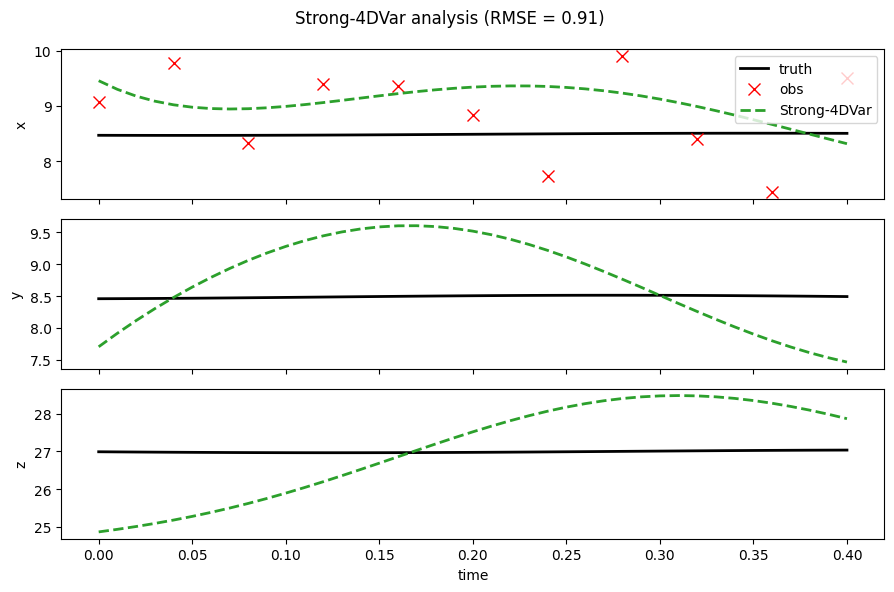

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
t = jnp.arange(prob.T_plus_1) * prob.dt
for i, ax in enumerate(axs):
    ax.plot(t, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_t = t[prob.mask[:, i] > 0.5]
    if len(obs_t) > 0:
        ax.plot(obs_t, prob.obs[prob.mask[:, i] > 0.5, i], "rx", ms=8, label="obs")
    ax.plot(t, result.mean[:, i], "C2--", lw=2, label="Strong-4DVar")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right")
axs[-1].set_xlabel("time")
fig.suptitle(f"Strong-4DVar analysis (RMSE = {result.rmse_total:.2f})")
fig.tight_layout()
plt.show()

## 5. Discussion

Order-of-magnitude RMSE improvement over OI / 3DVar. The dynamics
constraint compresses the 123 unknowns into the 3-dimensional
initial condition — the system is now overdetermined (11 obs vs 3
unknowns), so the optimiser can recover $x_0$ very precisely.

This is the canonical demonstration of why 4DVar matters for
chaotic systems. Subsequent notebooks vary the rigidity of the
constraint ([weak-4DVar](04_weak_4dvar.ipynb)), the inner-solver
strategy ([incremental-4DVar](05_incremental_4dvar.ipynb)), and the
solver type entirely ([FourDVarNet](06_fourdvarnet.ipynb) — a
*learned* iteration).